# Predictive Forecasting of Care Load & Placement Demand

# Notebook 06 – Future Forecasting & Model Inference

---

# Business Objective

The objective of this notebook is to use the trained forecasting model developed in Notebook 05 to generate future predictions for HHS Care occupancy.

This notebook demonstrates how the saved machine learning model can be deployed to estimate future care demand using historical operational data and engineered features.

The generated forecasts support proactive planning, resource allocation, staffing decisions, and operational preparedness.

# Business Questions

This notebook aims to answer the following questions:

1. How can the trained forecasting model be used for future prediction?

2. What is the predicted HHS Care demand for upcoming observations?

3. How can future forecasts support operational decision-making?

4. How can prediction results be exported for deployment and reporting?

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

plt.style.use("ggplot")
%matplotlib inline

## Business Insight

The notebook loads only the libraries required for model inference and visualization. Unlike model training, no machine learning algorithms are retrained during this stage.

In [34]:
model = joblib.load("../models/best_forecasting_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


## Business Insight

The previously trained Random Forest model is loaded from disk, ensuring consistent forecasting without requiring model retraining.

In [35]:
df = pd.read_csv("../data/processed/HHS_UAC_Feature_Engineered.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,...,Weekend,HHS_Lag_1,HHS_Lag_7,HHS_Lag_14,HHS_Lag_30,Rolling7,Rolling14,Rolling30,GrowthRate,Target
0,2023-03-08,113.0,208.0,159.0,7885,291.0,2023,3,1,10,...,0,7859.0,7914.0,7483.0,6566.0,7835.571429,7855.785714,7735.166667,0.003308,7786.0
1,2023-03-09,174.0,285.0,150.0,7786,340.0,2023,3,1,10,...,0,7885.0,7609.0,7794.0,7122.0,7860.857143,7855.214286,7757.300000,-0.012555,7567.0
2,2023-03-13,104.0,230.0,206.0,7567,249.0,2023,3,1,11,...,0,7786.0,7800.0,7869.0,7280.0,7827.571429,7833.642857,7766.866667,-0.028127,7810.0
3,2023-03-14,147.0,276.0,214.0,7810,181.0,2023,3,1,11,...,0,7567.0,7896.0,7793.0,7433.0,7815.285714,7834.857143,7779.433333,0.032113,7915.0
4,2023-03-15,108.0,220.0,213.0,7915,286.0,2023,3,1,11,...,0,7810.0,7930.0,7817.0,7538.0,7813.142857,7841.857143,7792.000000,0.013444,7989.0


## Business Insight

The feature engineered dataset contains the same predictor variables used during model training, ensuring compatibility during inference.

In [36]:
X = df.drop(columns=["Date", "Target"])

X.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,Day,DayOfWeek,Weekend,HHS_Lag_1,HHS_Lag_7,HHS_Lag_14,HHS_Lag_30,Rolling7,Rolling14,Rolling30,GrowthRate
0,113.0,208.0,159.0,7885,291.0,2023,3,1,10,8,2,0,7859.0,7914.0,7483.0,6566.0,7835.571429,7855.785714,7735.166667,0.003308
1,174.0,285.0,150.0,7786,340.0,2023,3,1,10,9,3,0,7885.0,7609.0,7794.0,7122.0,7860.857143,7855.214286,7757.300000,-0.012555
2,104.0,230.0,206.0,7567,249.0,2023,3,1,11,13,0,0,7786.0,7800.0,7869.0,7280.0,7827.571429,7833.642857,7766.866667,-0.028127
3,147.0,276.0,214.0,7810,181.0,2023,3,1,11,14,1,0,7567.0,7896.0,7793.0,7433.0,7815.285714,7834.857143,7779.433333,0.032113
4,108.0,220.0,213.0,7915,286.0,2023,3,1,11,15,2,0,7810.0,7930.0,7817.0,7538.0,7813.142857,7841.857143,7792.000000,0.013444


## Business Insight

Only predictor variables are supplied to the forecasting model. The target variable is excluded because it represents the value to be predicted.

In [37]:
future_prediction = model.predict(X)

future_prediction[:10]

array([7849.82 , 7541.885, 7434.67 , 7928.83 , 7967.635, 7945.695,
       7928.85 , 8017.17 , 8109.955, 8145.845])

## Business Insight

The trained forecasting model estimates future HHS Care occupancy using historical operational indicators and engineered temporal features.

In [38]:
forecast = pd.DataFrame({
    "Date": df["Date"],
    "Predicted_HHS_Care": future_prediction
})

forecast.head()

,Date,Predicted_HHS_Care
0,2023-03-08,7849.820
1,2023-03-09,7541.885
2,2023-03-13,7434.670
3,2023-03-14,7928.830
4,2023-03-15,7967.635


## Business Insight

The prediction results are organized into a structured forecasting table, making them suitable for reporting and downstream analytical workflows.

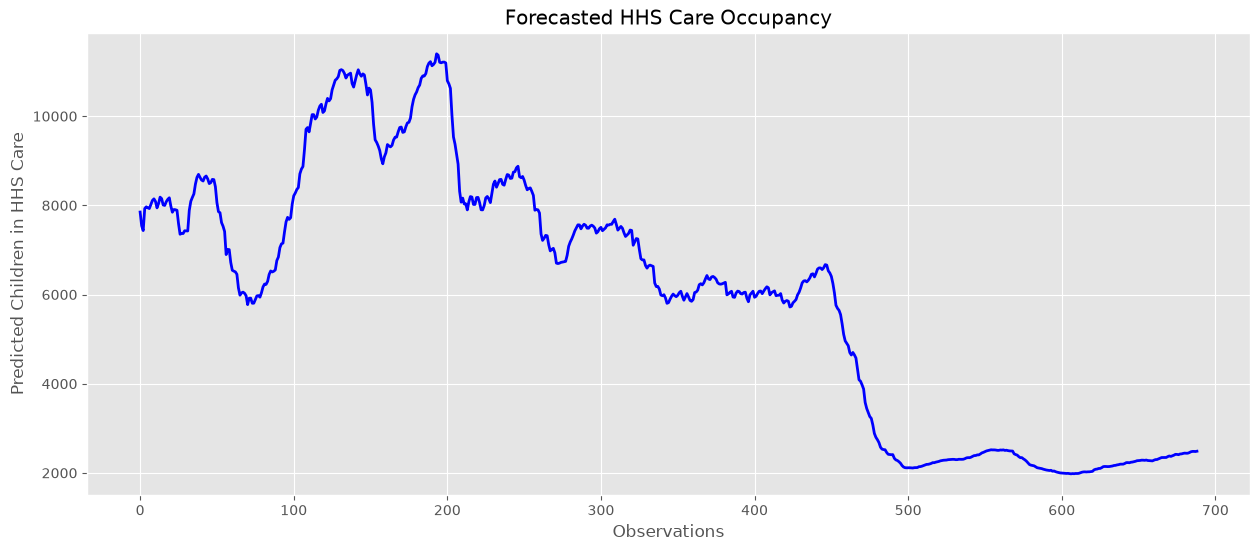

In [39]:
plt.figure(figsize=(15,6))

plt.plot(
    forecast["Predicted_HHS_Care"],
    color="blue",
    linewidth=2
)

plt.title("Forecasted HHS Care Occupancy")

plt.xlabel("Observations")

plt.ylabel("Predicted Children in HHS Care")

plt.show()

## Business Insight

The forecast visualization highlights expected variations in future HHS Care occupancy, enabling decision-makers to anticipate periods of increased operational demand.

In [40]:
forecast.to_csv(
    "../results/future_forecast.csv",
    index=False
)

print("Future forecast saved successfully.")

Future forecast saved successfully.


## Business Insight

Forecast results are exported for integration into dashboards, reporting systems, and operational planning processes.

# Prediction Statistics

The following descriptive statistics summarize the overall forecast distribution generated by the trained forecasting model.

In [41]:
forecast["Predicted_HHS_Care"].describe()

count      689.000000
mean      5988.785080
std       2871.815807
min       1978.950000
25%       2440.620000
50%       6263.765000
75%       8062.685000
max      11398.660000
Name: Predicted_HHS_Care, dtype: float64

## Business Insight

The statistical summary provides an overview of the expected occupancy levels. Decision-makers can use these values to understand the average forecast, expected variability, and the operational range of future care demand.

# Forecast Distribution

The histogram below illustrates the distribution of forecasted HHS Care occupancy values.

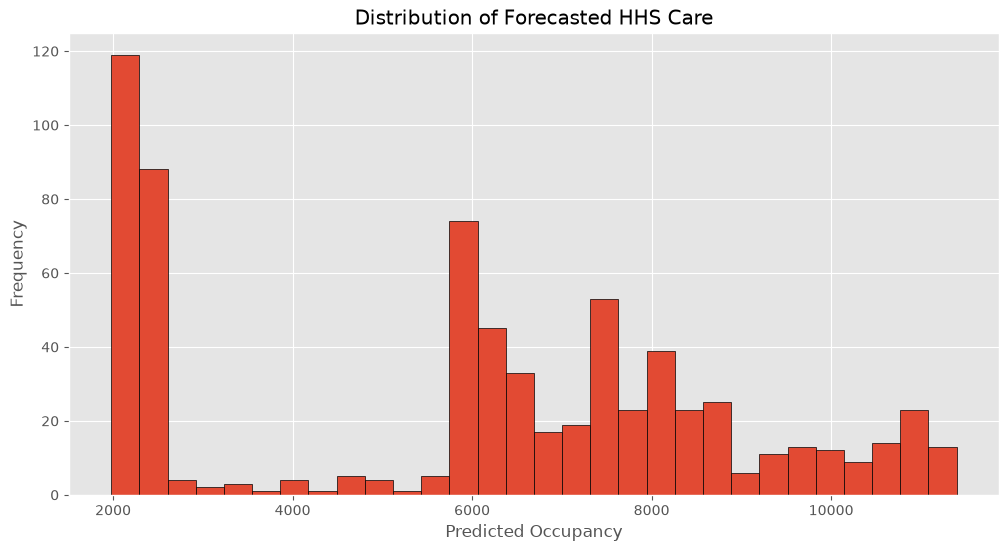

In [42]:
plt.figure(figsize=(12,6))

plt.hist(
    forecast["Predicted_HHS_Care"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Forecasted HHS Care")

plt.xlabel("Predicted Occupancy")

plt.ylabel("Frequency")

plt.show()

## Business Insight

The distribution reveals whether the forecasted care demand remains concentrated around a stable level or exhibits substantial variability. This helps planners evaluate future operational stability.

# Top 10 Highest Forecasted Occupancy

In [43]:
forecast.nlargest(
    10,
    "Predicted_HHS_Care"
)

,Date,Predicted_HHS_Care
193,2023-12-19,11398.660
194,2023-12-20,11368.975
189,2023-12-13,11222.815
198,2023-12-27,11213.520
197,2023-12-26,11212.315
192,2023-12-18,11209.685
195,2023-12-21,11208.825
196,2023-12-25,11197.270
199,2023-12-28,11193.620
188,2023-12-12,11189.820


## Business Insight

The highest predicted occupancy periods represent potential resource-intensive situations requiring additional staffing, housing capacity, and operational readiness.

# Top 10 Lowest Forecasted Occupancy

In [44]:
forecast.nsmallest(
    10,
    "Predicted_HHS_Care"
)

,Date,Predicted_HHS_Care
606,2025-08-20,1978.950
608,2025-08-24,1981.510
607,2025-08-21,1984.305
605,2025-08-19,1984.505
610,2025-08-26,1985.995
609,2025-08-25,1986.955
603,2025-08-17,1987.575
611,2025-08-27,1989.010
604,2025-08-18,1989.525
602,2025-08-14,1991.165


## Business Insight

Periods with lower projected occupancy provide opportunities for maintenance activities, resource optimization, staff training, and budget control.

# Rolling Forecast Trend

A rolling average smooths short-term fluctuations and highlights the long-term forecasting trend.

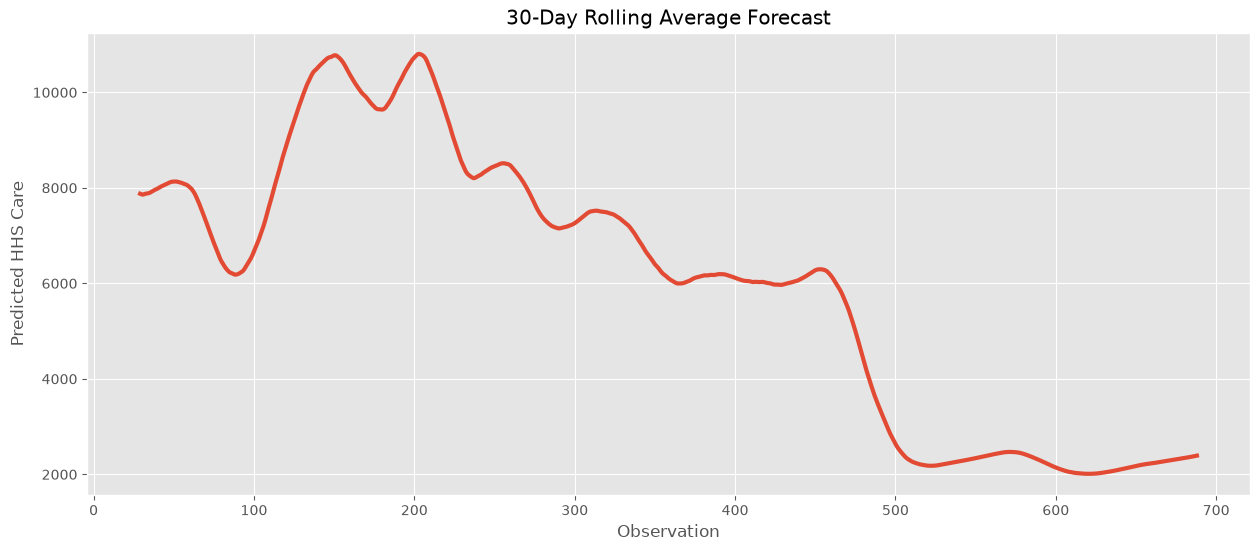

In [45]:
forecast["Rolling_Mean"] = (
    forecast["Predicted_HHS_Care"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    forecast["Rolling_Mean"],
    linewidth=3
)

plt.title("30-Day Rolling Average Forecast")

plt.xlabel("Observation")

plt.ylabel("Predicted HHS Care")

plt.show()

## Business Insight

The rolling average identifies sustained increases or decreases in projected occupancy, allowing management teams to recognize long-term operational trends rather than daily fluctuations.

# Forecast Summary Table

In [46]:
summary = pd.DataFrame({

    "Metric":[
        "Minimum",
        "Maximum",
        "Average",
        "Median",
        "Standard Deviation"
    ],

    "Value":[

        forecast["Predicted_HHS_Care"].min(),

        forecast["Predicted_HHS_Care"].max(),

        forecast["Predicted_HHS_Care"].mean(),

        forecast["Predicted_HHS_Care"].median(),

        forecast["Predicted_HHS_Care"].std()

    ]

})

summary

,Metric,Value
0,Minimum,1978.950000
1,Maximum,11398.660000
2,Average,5988.785080
3,Median,6263.765000
4,Standard Deviation,2871.815807


## Business Insight

The summary table provides executives with a concise overview of the expected forecast behavior and can be directly incorporated into reporting dashboards.

# Save Forecast Summary

In [47]:
summary.to_csv(

    "../results/forecast_summary.csv",

    index=False

)

print("Forecast summary saved successfully.")

Forecast summary saved successfully.


## Business Insight

Saving the summary enables seamless integration with reporting pipelines, executive dashboards, and automated decision-support systems.

# Business Recommendation

Based on the forecasting results, HHS decision-makers should continuously monitor predicted occupancy levels to optimize staffing, shelter capacity, budgeting, and emergency preparedness. Periodic model retraining with newly available operational data will further improve forecasting accuracy and maintain long-term predictive performance.

# Project Summary

The trained Random Forest forecasting model was successfully loaded and applied to the engineered dataset.

Future HHS Care occupancy predictions were generated, visualized, and exported for operational use.

The forecasting pipeline demonstrates how machine learning models can transition from development into practical business applications without retraining.

# Final Business Conclusion

This notebook completes the end-to-end forecasting workflow by transforming a trained machine learning model into a reusable prediction engine.

The generated forecasts provide HHS decision-makers with valuable forward-looking intelligence for proactive resource planning, staffing optimization, budgeting, and emergency preparedness.

Together with the previous notebooks, this project establishes a complete predictive analytics pipeline covering data understanding, cleaning, exploratory analysis, feature engineering, predictive modeling, and future forecasting.